In [ ]:
import torch
import torch.nn.functional as F
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np

In [191]:
TOKENIZER = {
    0: "all",
    1: "Brocolli",
    2: "coffee",
    3: "is",
    4: "sleep"
}

In [181]:
DETOKENIZER = { v: k for (k,v) in TOKENIZER.items() }

In [221]:
from pprint import pprint 
pprint(DETOKENIZER)

{'Brocolli': 2, 'all': 1, 'coffee': 3, 'is': 4, 'sleep': 5}


In [194]:
DETOKENIZER.get("is")

4

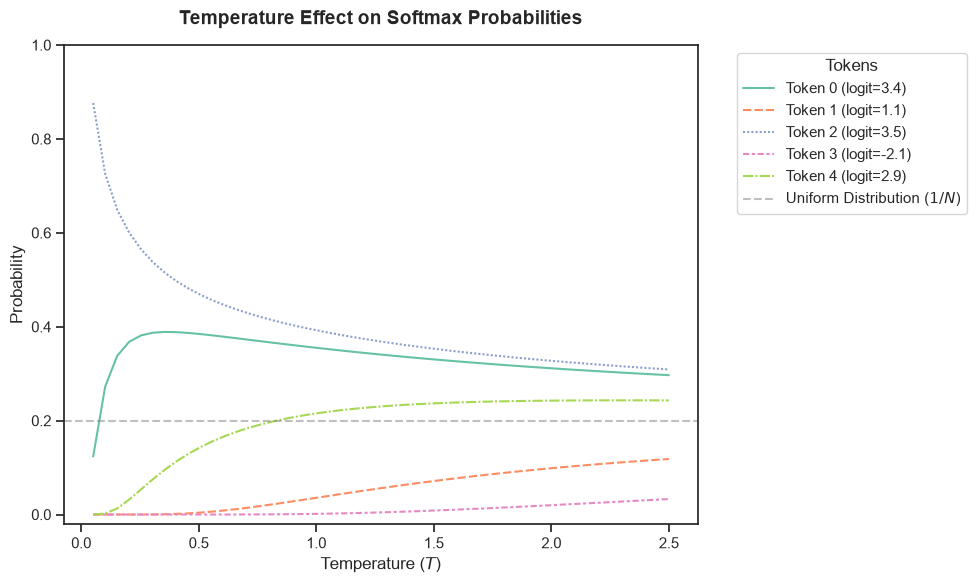

In [ ]:


logits = torch.tensor([3.4, 1.1, 3.5, -2.1, 2.9])
token_names = [f"Token {i} (logit={val:.1f})" for i, val in enumerate(logits)]
temperatures = torch.linspace(0.0, 2.5, 50)

data = []
for temp in temperatures:
    scaled_logits = logits / temp
    probs = F.softmax(scaled_logits, dim=-1)
    
    for token_label, prob in zip(token_names, probs):
        data.append({
            "Temperature": temp.item(),
            "Token": token_label,
            "Probability": prob.item()
        })

df = pd.DataFrame(data)

sns.set_theme(style="ticks")
plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=df,
    x="Temperature",
    y="Probability",
    hue="Token",
    style="Token",
    linewidth=1.5,
    palette="Set2"
)

# Personalización del gráfico
plt.title("Temperature Effect on Softmax Probabilities", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Temperature ($T$)", fontsize=12)
plt.ylabel("Probability", fontsize=12)
plt.ylim(-0.02, 1.0)
plt.axhline(1/len(logits), color='gray', linestyle='--', alpha=0.5, label="Uniform Distribution ($1/N$)")

plt.legend(title="Tokens", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(False)
plt.show()

In [213]:
df

,Temperatura,Token,Probability
0,0.1,Token 0 (logit=3.4),2.684550e-01
1,0.1,Token 1 (logit=1.1),2.754852e-11
2,0.1,Token 2 (logit=3.5),7.297363e-01
3,0.1,Token 3 (logit=-2.1),3.488791e-25
4,0.1,Token 4 (logit=2.9),1.808835e-03
...,...,...,...
495,2.5,Token 0 (logit=3.4),2.968360e-01
496,2.5,Token 1 (logit=1.1),1.182948e-01
497,2.5,Token 2 (logit=3.5),3.089501e-01
498,2.5,Token 3 (logit=-2.1),3.289036e-02


In [229]:
df.query("Temperature == 0.99")

,Temperature,Token,Probability


In [231]:
 F.softmax(logits, dim=-1)

tensor([0.3551, 0.0356, 0.3925, 0.0015, 0.2154])

In [ ]:


data = {
    'token': ['pizza', 'tacos', 'burger', 'sushi', 'pasta', 'salad', 'soup', 'ramen', 'steak', 'pancakes'],
    'logit': [1.5, 1.8, 0.2, 1.5, 2.1, 2.0, 1.2, 2.8, 0.05, -2.0]
}

df = pd.DataFrame(data)

def softmax(logits):
    exp_logits = np.exp(logits - np.max(logits))
    return exp_logits / exp_logits.sum()

df['probability'] = softmax(df['logit'])

df = df.sort_values(by='probability', ascending=False).reset_index(drop=True)

df['cumulative_prob'] = df['probability'].cumsum()

# Top-K Sampling
def apply_top_k(df_input, k=3):
    df_k = df_input.head(k).copy()
    df_k['normalized_prob'] = df_k['probability'] / df_k['probability'].sum()
    return df_k[['token', 'logit', 'probability', 'normalized_prob']]

# Top-P
def apply_top_p(df_input, p=0.90):
    """top p"""
    mask = df_input['cumulative_prob'].shift(1, fill_value=0) < p
    df_p = df_input[mask].copy()

    df_p['normalized_prob'] = df_p['probability'] / df_p['probability'].sum()
    return df_p[['token', 'logit', 'probability', 'cumulative_prob', 'normalized_prob']]

# Display Results
print("=== VOCABULARIO COMPLETO ORDENADO ===")
print(df[['token', 'logit', 'probability', 'cumulative_prob']].to_string(index=False))

print("\n=== TOP-K (K = 3) ===")
print(apply_top_k(df, k=3).to_string(index=False))

print("\n=== TOP-P (P = 0.90) ===")
print(apply_top_p(df, p=0.90).to_string(index=False))

=== VOCABULARIO COMPLETO ORDENADO ===
   token  logit  probability  cumulative_prob
   ramen   2.80     0.311800         0.311800
   pasta   2.10     0.154835         0.466635
   salad   2.00     0.140101         0.606736
   tacos   1.80     0.114705         0.721441
   pizza   1.50     0.084975         0.806416
   sushi   1.50     0.084975         0.891391
    soup   1.20     0.062951         0.954343
  burger   0.20     0.023158         0.977501
   steak   0.05     0.019933         0.997434
pancakes  -2.00     0.002566         1.000000

=== TOP-K (K = 3) ===
token  logit  probability  normalized_prob
ramen    2.8     0.311800         0.513897
pasta    2.1     0.154835         0.255194
salad    2.0     0.140101         0.230909

=== TOP-P (P = 0.90) ===
token  logit  probability  cumulative_prob  normalized_prob
ramen    2.8     0.311800         0.311800         0.326717
pasta    2.1     0.154835         0.466635         0.162243
salad    2.0     0.140101         0.606736         0.14

In [240]:
df[['token', 'logit', 'probability', 'cumulative_prob']]

,token,logit,probability,cumulative_prob
0,ramen,2.80,0.311800,0.311800
1,pasta,2.10,0.154835,0.466635
2,salad,2.00,0.140101,0.606736
3,tacos,1.80,0.114705,0.721441
4,pizza,1.50,0.084975,0.806416
5,sushi,1.50,0.084975,0.891391
6,soup,1.20,0.062951,0.954343
7,burger,0.20,0.023158,0.977501
8,steak,0.05,0.019933,0.997434
9,pancakes,-2.00,0.002566,1.000000
